# Instruction for Data time drift removal

The instructional document aims to guide users in using the `detrend` function in the `occ.drift` module to remove linear trend or drift from time series data.

It's also an alternative function for dedrifting without momlevel or numpy's polyfit.

> The occ.drift.detrend function uses the least squares (OLS) method to fit a linear trend in the data over time and subtracts this trend from the original data to obtain the drift-de-rifted data.

| Parameter Name | Data Type | Description |
| :--- | :--- | :--- |
| `da` | $\text{xarray.DataArray}$ | **Must** be a single $\text{DataArray}$ (not $\text{DataSet}$), and must contain the $\text{'time'}$ dimension. |
| `variable\_name` | $\text{String}$ | The name of the original variable, such as `'sst'`, `'zos'`. This name will be used to name the new array in the output $\text{DataSet}$. |

* **Output:** A $\text{xarray.Dataset}$ containing the following five $\text{DataArray}$:

* `[variable_name]_slope`: The slope of the data's time trend.

* `[variable_name]_intercept`: The intercept of the trend line at the time origin.

* `[variable_name]_trend`: The complete time trend line (with the same dimensions as the original data).

* `[variable_name]_dedrifted`: Drift-free data after removing the linear trend.

* `[variable_name]_raw`: The original input $\text{DataArray}$.


The function calculates the linear trend $y = mt + b$ using the standard least squares formula:

1. **Time Variable Transformation:** Converts the time coordinates of $xarray$ to an integer array $t$ starting from $0$ for linear regression.

2. **Slope ($m$) Calculation:** Measures the ratio of the covariance of the data over time to the time variance:

$$m = \frac{\sum_{i=1}^{N} (y_i - \bar{y})(t_i - \bar{t})}{\sum_{i=1}^{N} (t_i - \bar{t})^2}$$

where $y$ is the data ($\text{da}$), $t$ is the time variable ($t_text{reshaped}$), and $\bar{y}$ and $\bar{t}$ are their averages, respectively.

3. **Intercept ($b$) Calculation:**

$$b = \bar{y} - m\bar{t}$$


4. **Detrended:** The final detrended data is the original data minus the **drift portion contributed only by the slope** ($m \cdot t$):


$$\text{Detrended} = y - (m \cdot t)$$

**Note:** The function **preserves** the intercept $b$, which ensures that the detrended data still fluctuates around its original mean or baseline, rather than forcing a center point of $\text{0}$.

In [ ]:
# import package
import matplotlib.pyplot as plt 
import xarray as xr
import numpy as np 
import occ

In [7]:
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 8,4  
plt.rcParams['figure.dpi'] = 300

In [ ]:
# Load OISST climate mean data and select variable "SST"
SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc',use_cftime=True)
SST = SST_OISST.sst

/var/folders/y3/jjb7h7fd4mg_yy8nsvfhwzym0000gn/T/ipykernel_84260/187261218.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc',use_cftime=True)


In [ ]:
# Perform the de-shift operation, passing in a DataArray and the variable name.
dsout = occ.drift.detrend(SST, 'sst')
dsout

<xarray.Dataset> Size: 17MB
Dimensions:        (lat: 180, lon: 360, time: 12)
Coordinates:
  * lat            (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon            (lon) float32 1kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * time           (time) object 96B 1991-01-01 00:00:00 ... 1991-12-01 00:00:00
Data variables:
    sst_slope      (lat, lon) float64 518kB 0.0 0.0 0.0 ... 0.0171 0.01722
    sst_intercept  (lat, lon) float64 518kB nan nan nan ... -1.706 -1.707 -1.707
    sst_dedrifted  (time, lat, lon) float64 6MB nan nan nan ... -1.916 -1.918
    sst_trend      (lat, lon, time) float64 6MB nan nan nan ... -1.534 -1.517
    sst_raw        (time, lat, lon) float32 3MB nan nan nan ... -1.728 -1.728

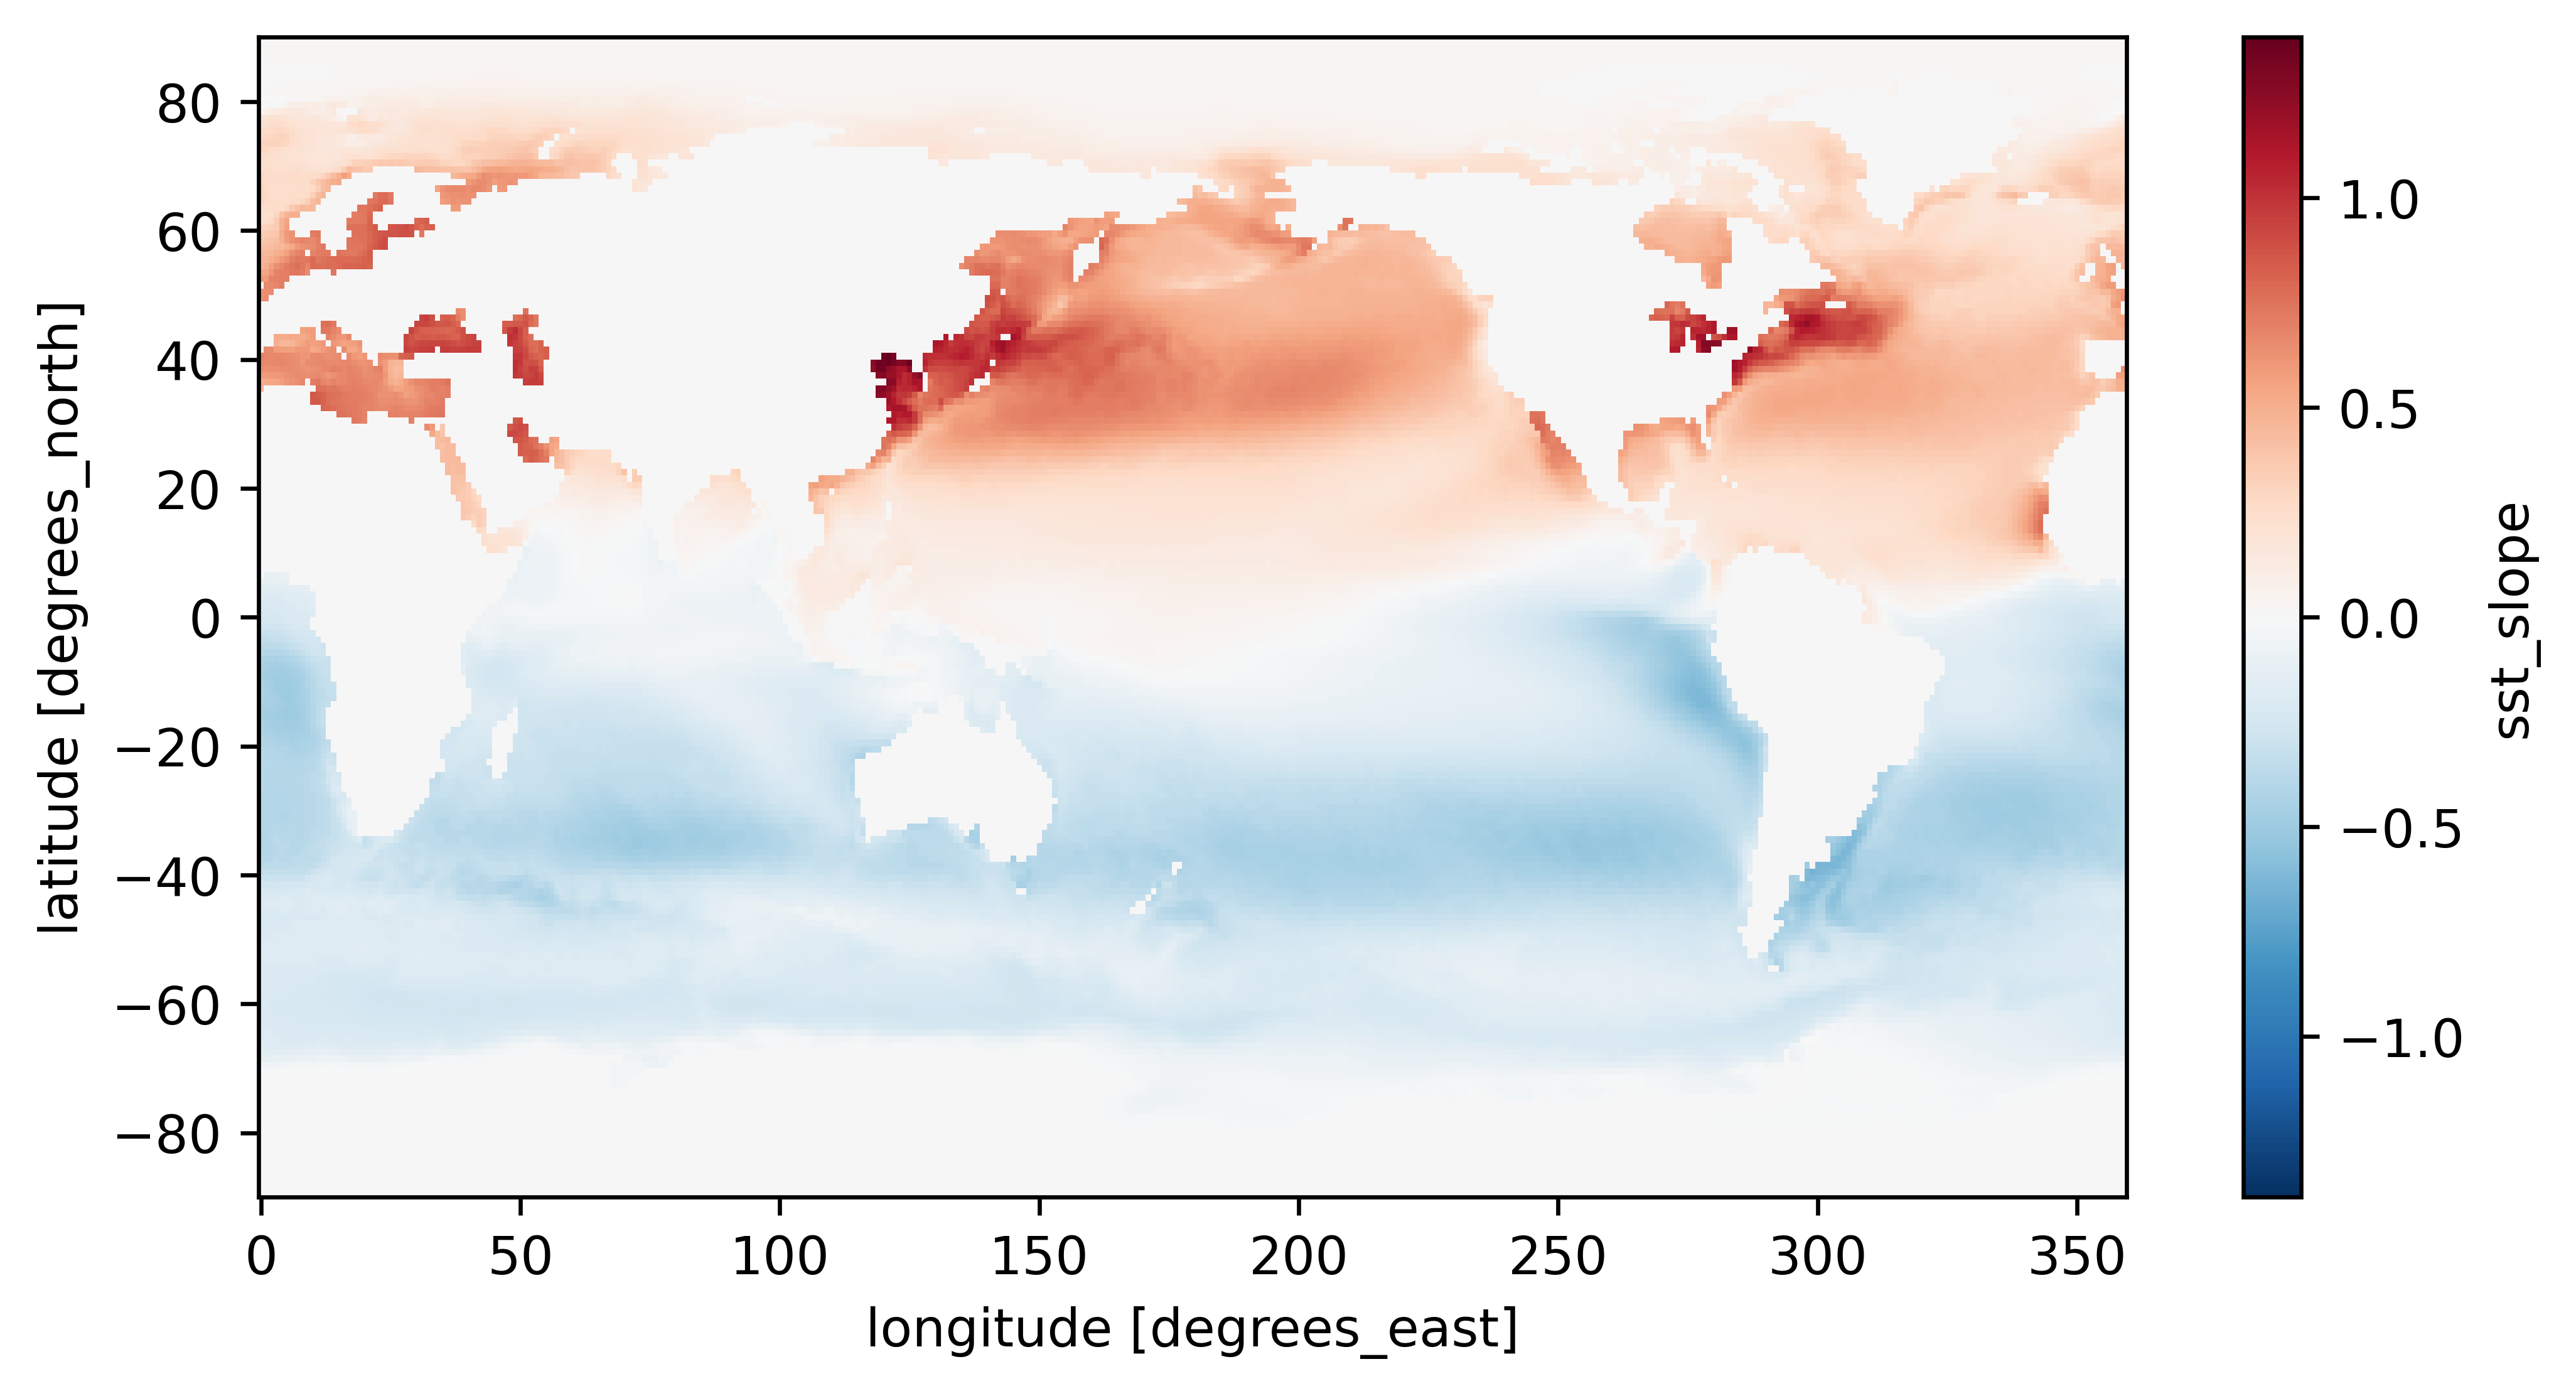

In [11]:
dsout.sst_slope.plot()

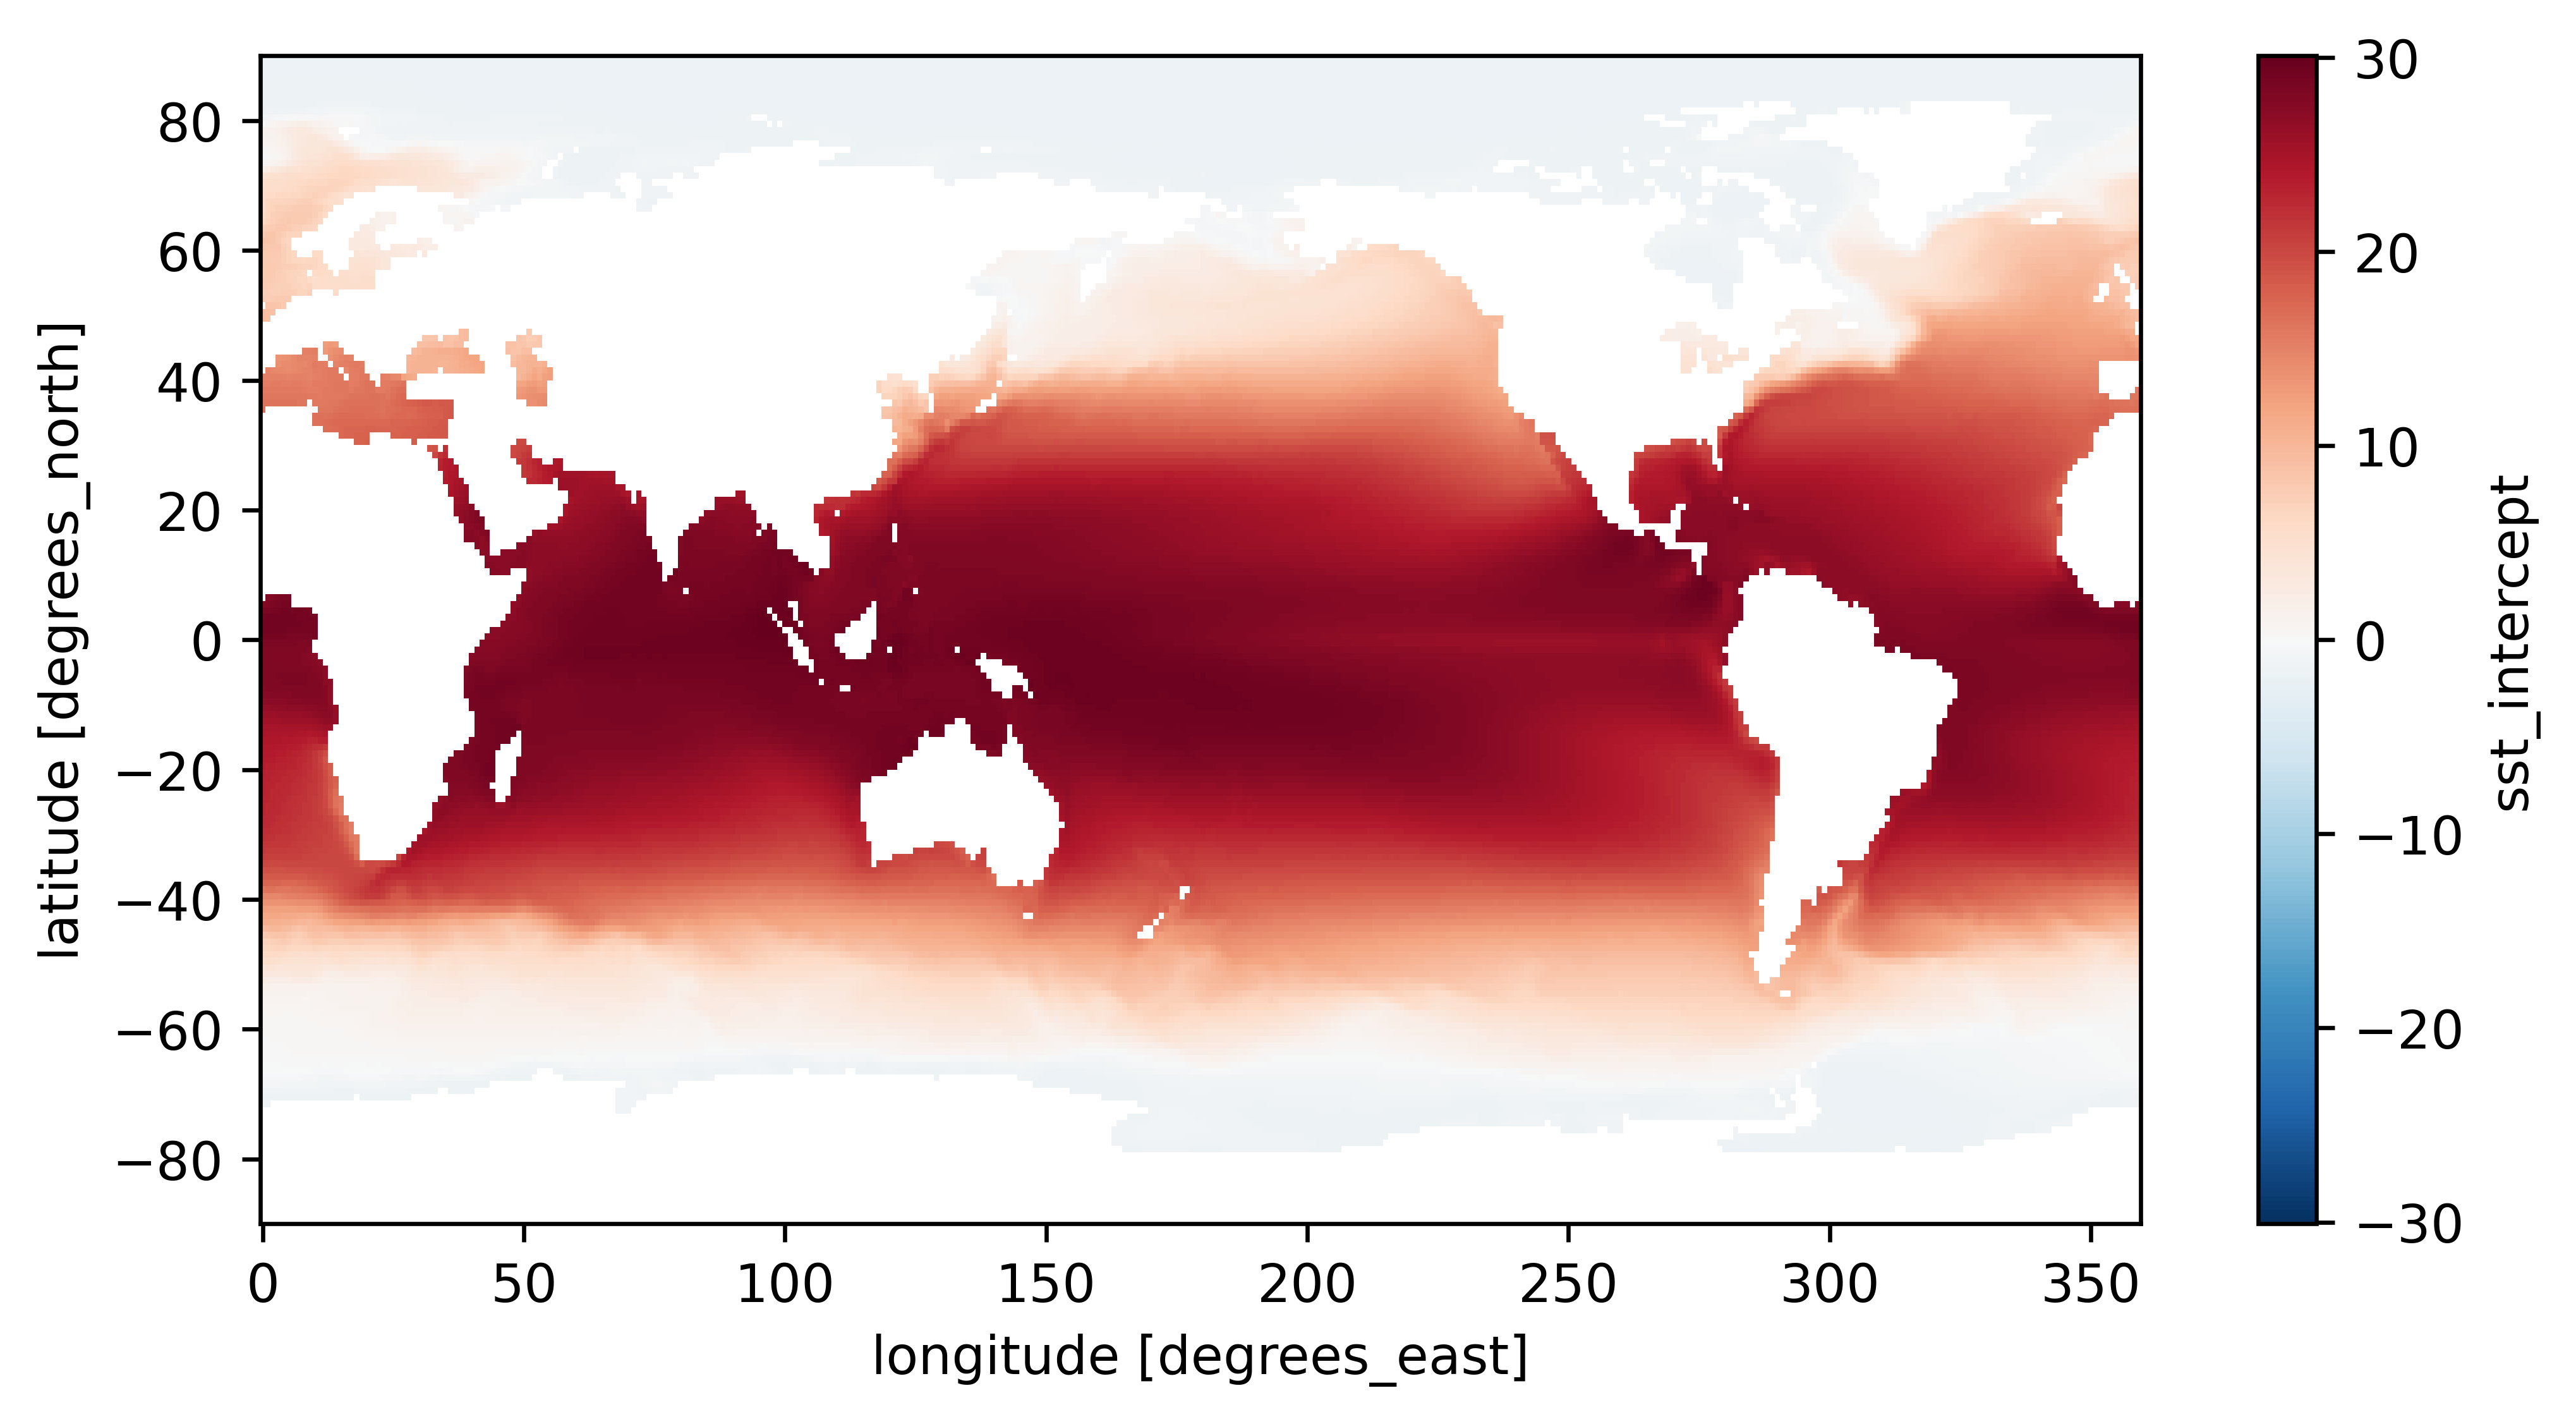

In [12]:
dsout.sst_intercept.plot()

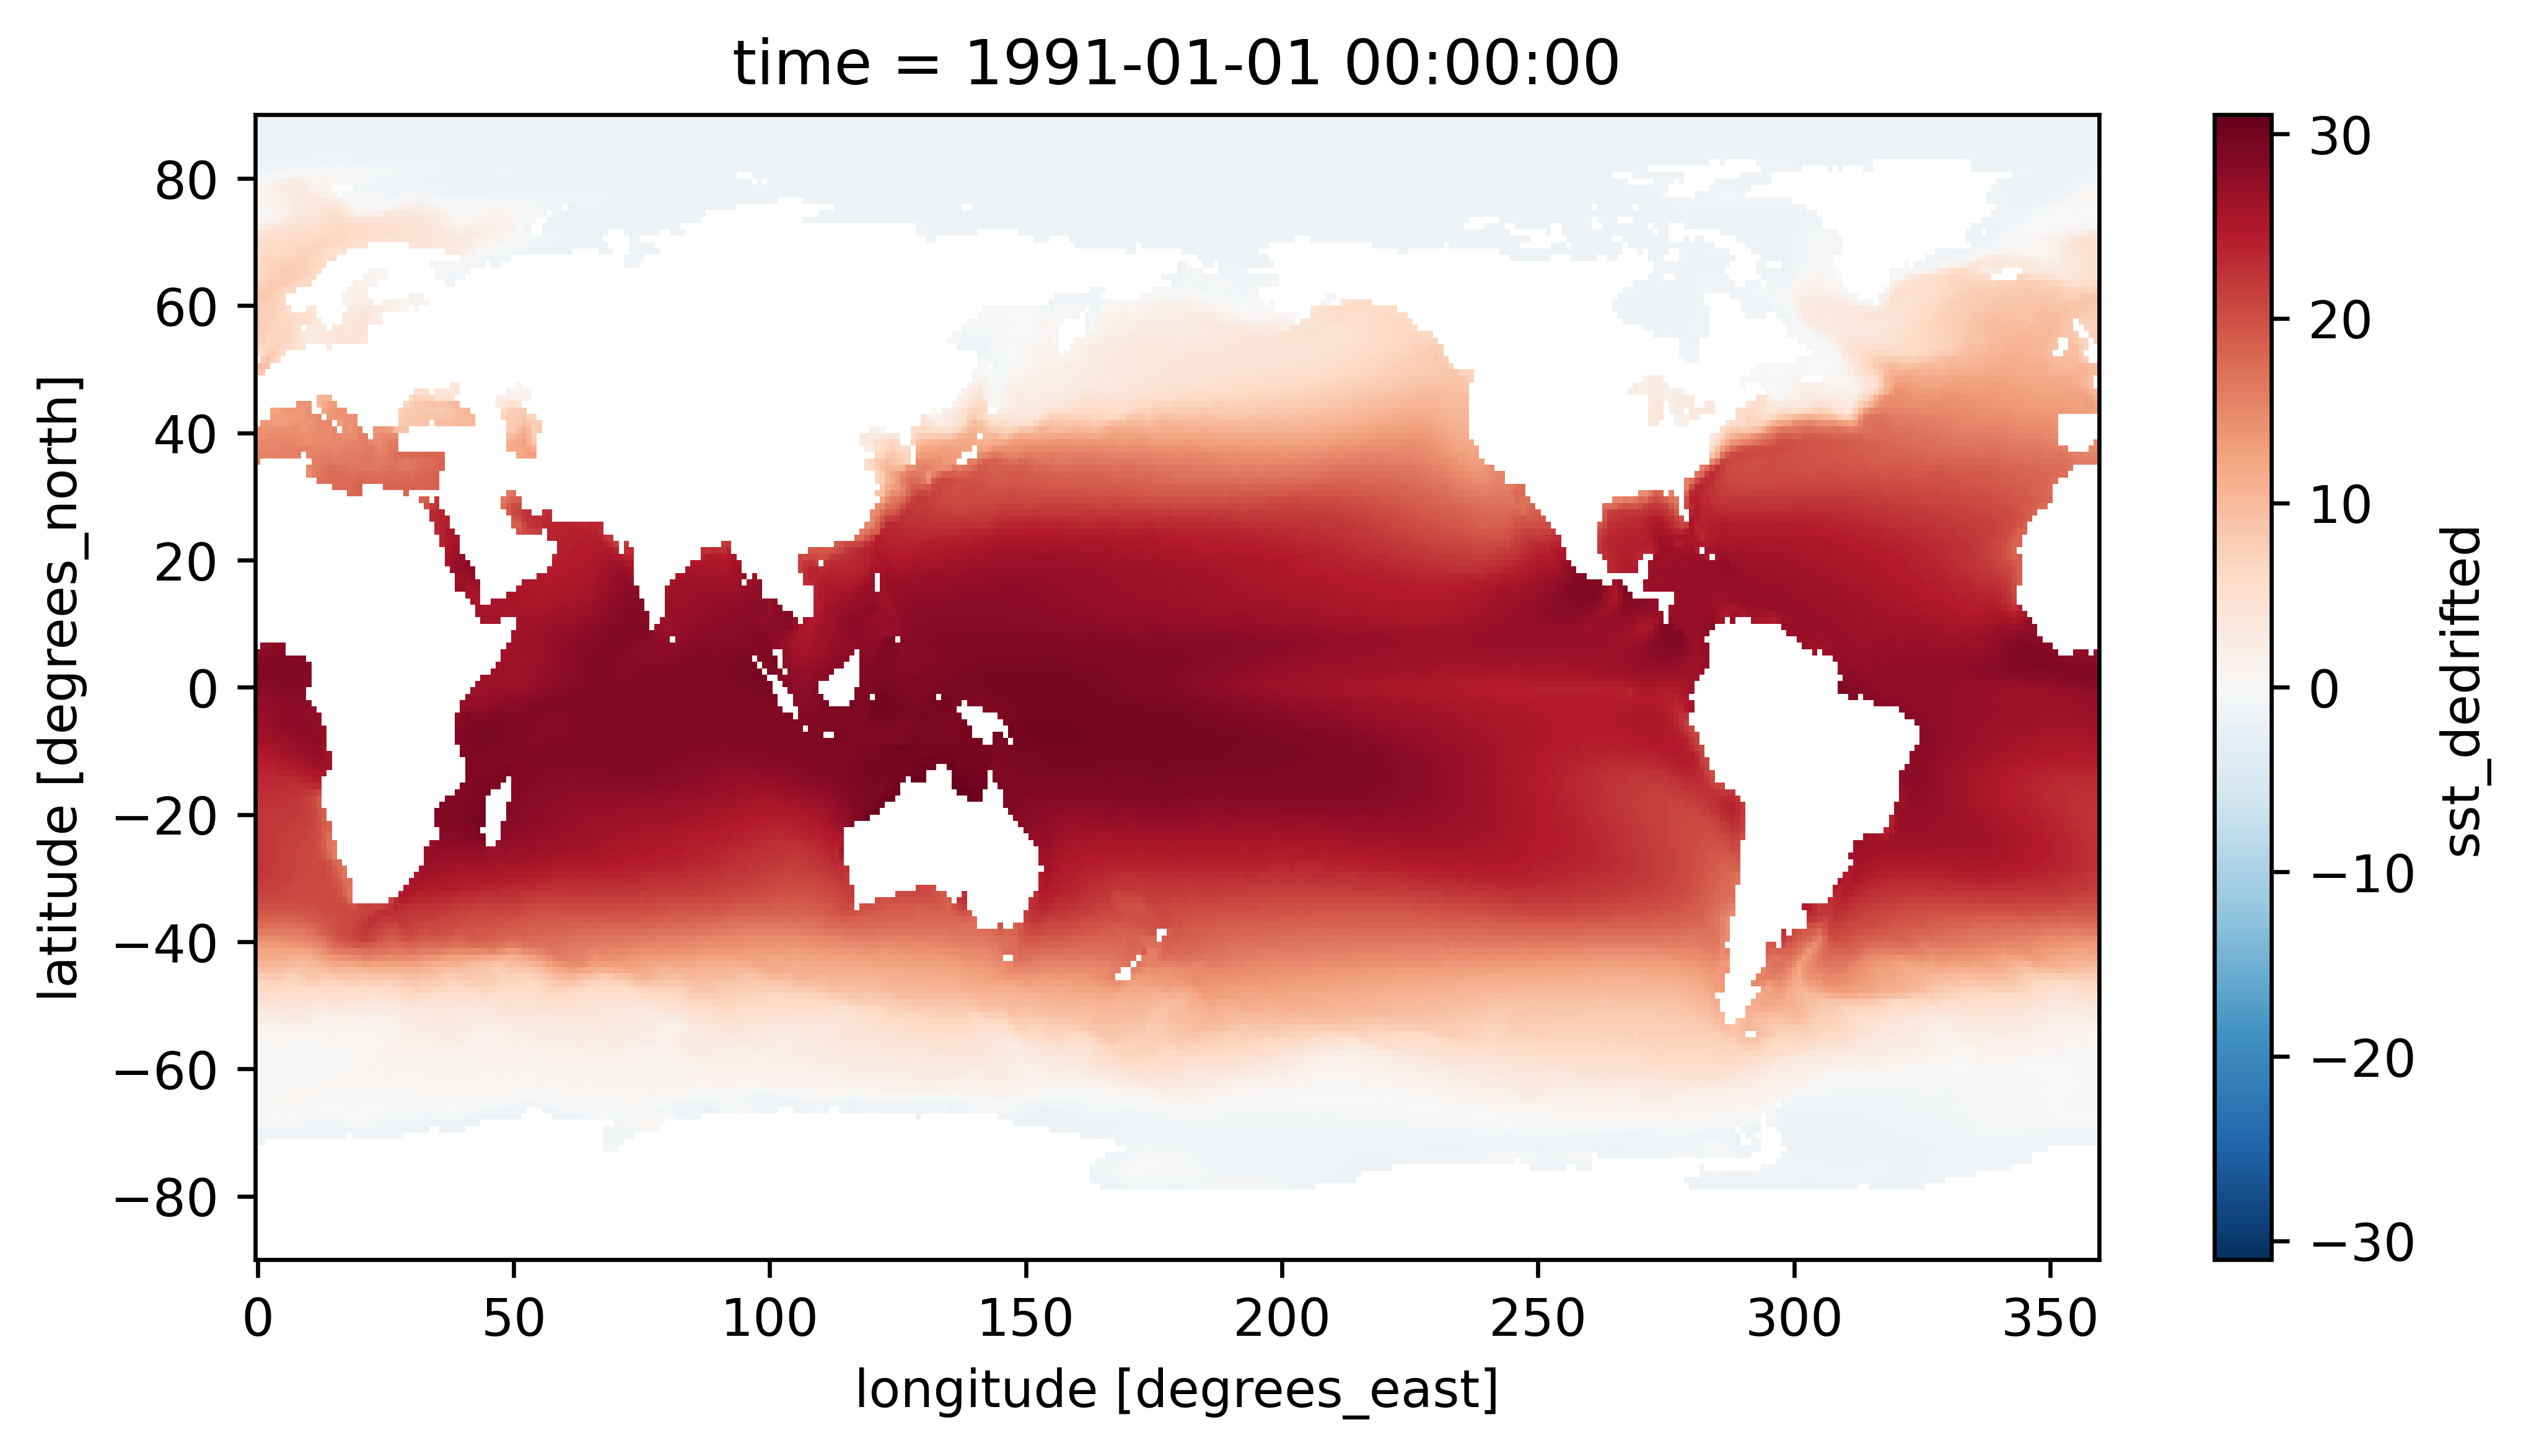

In [13]:
dsout.sst_dedrifted.isel(time=0).plot()

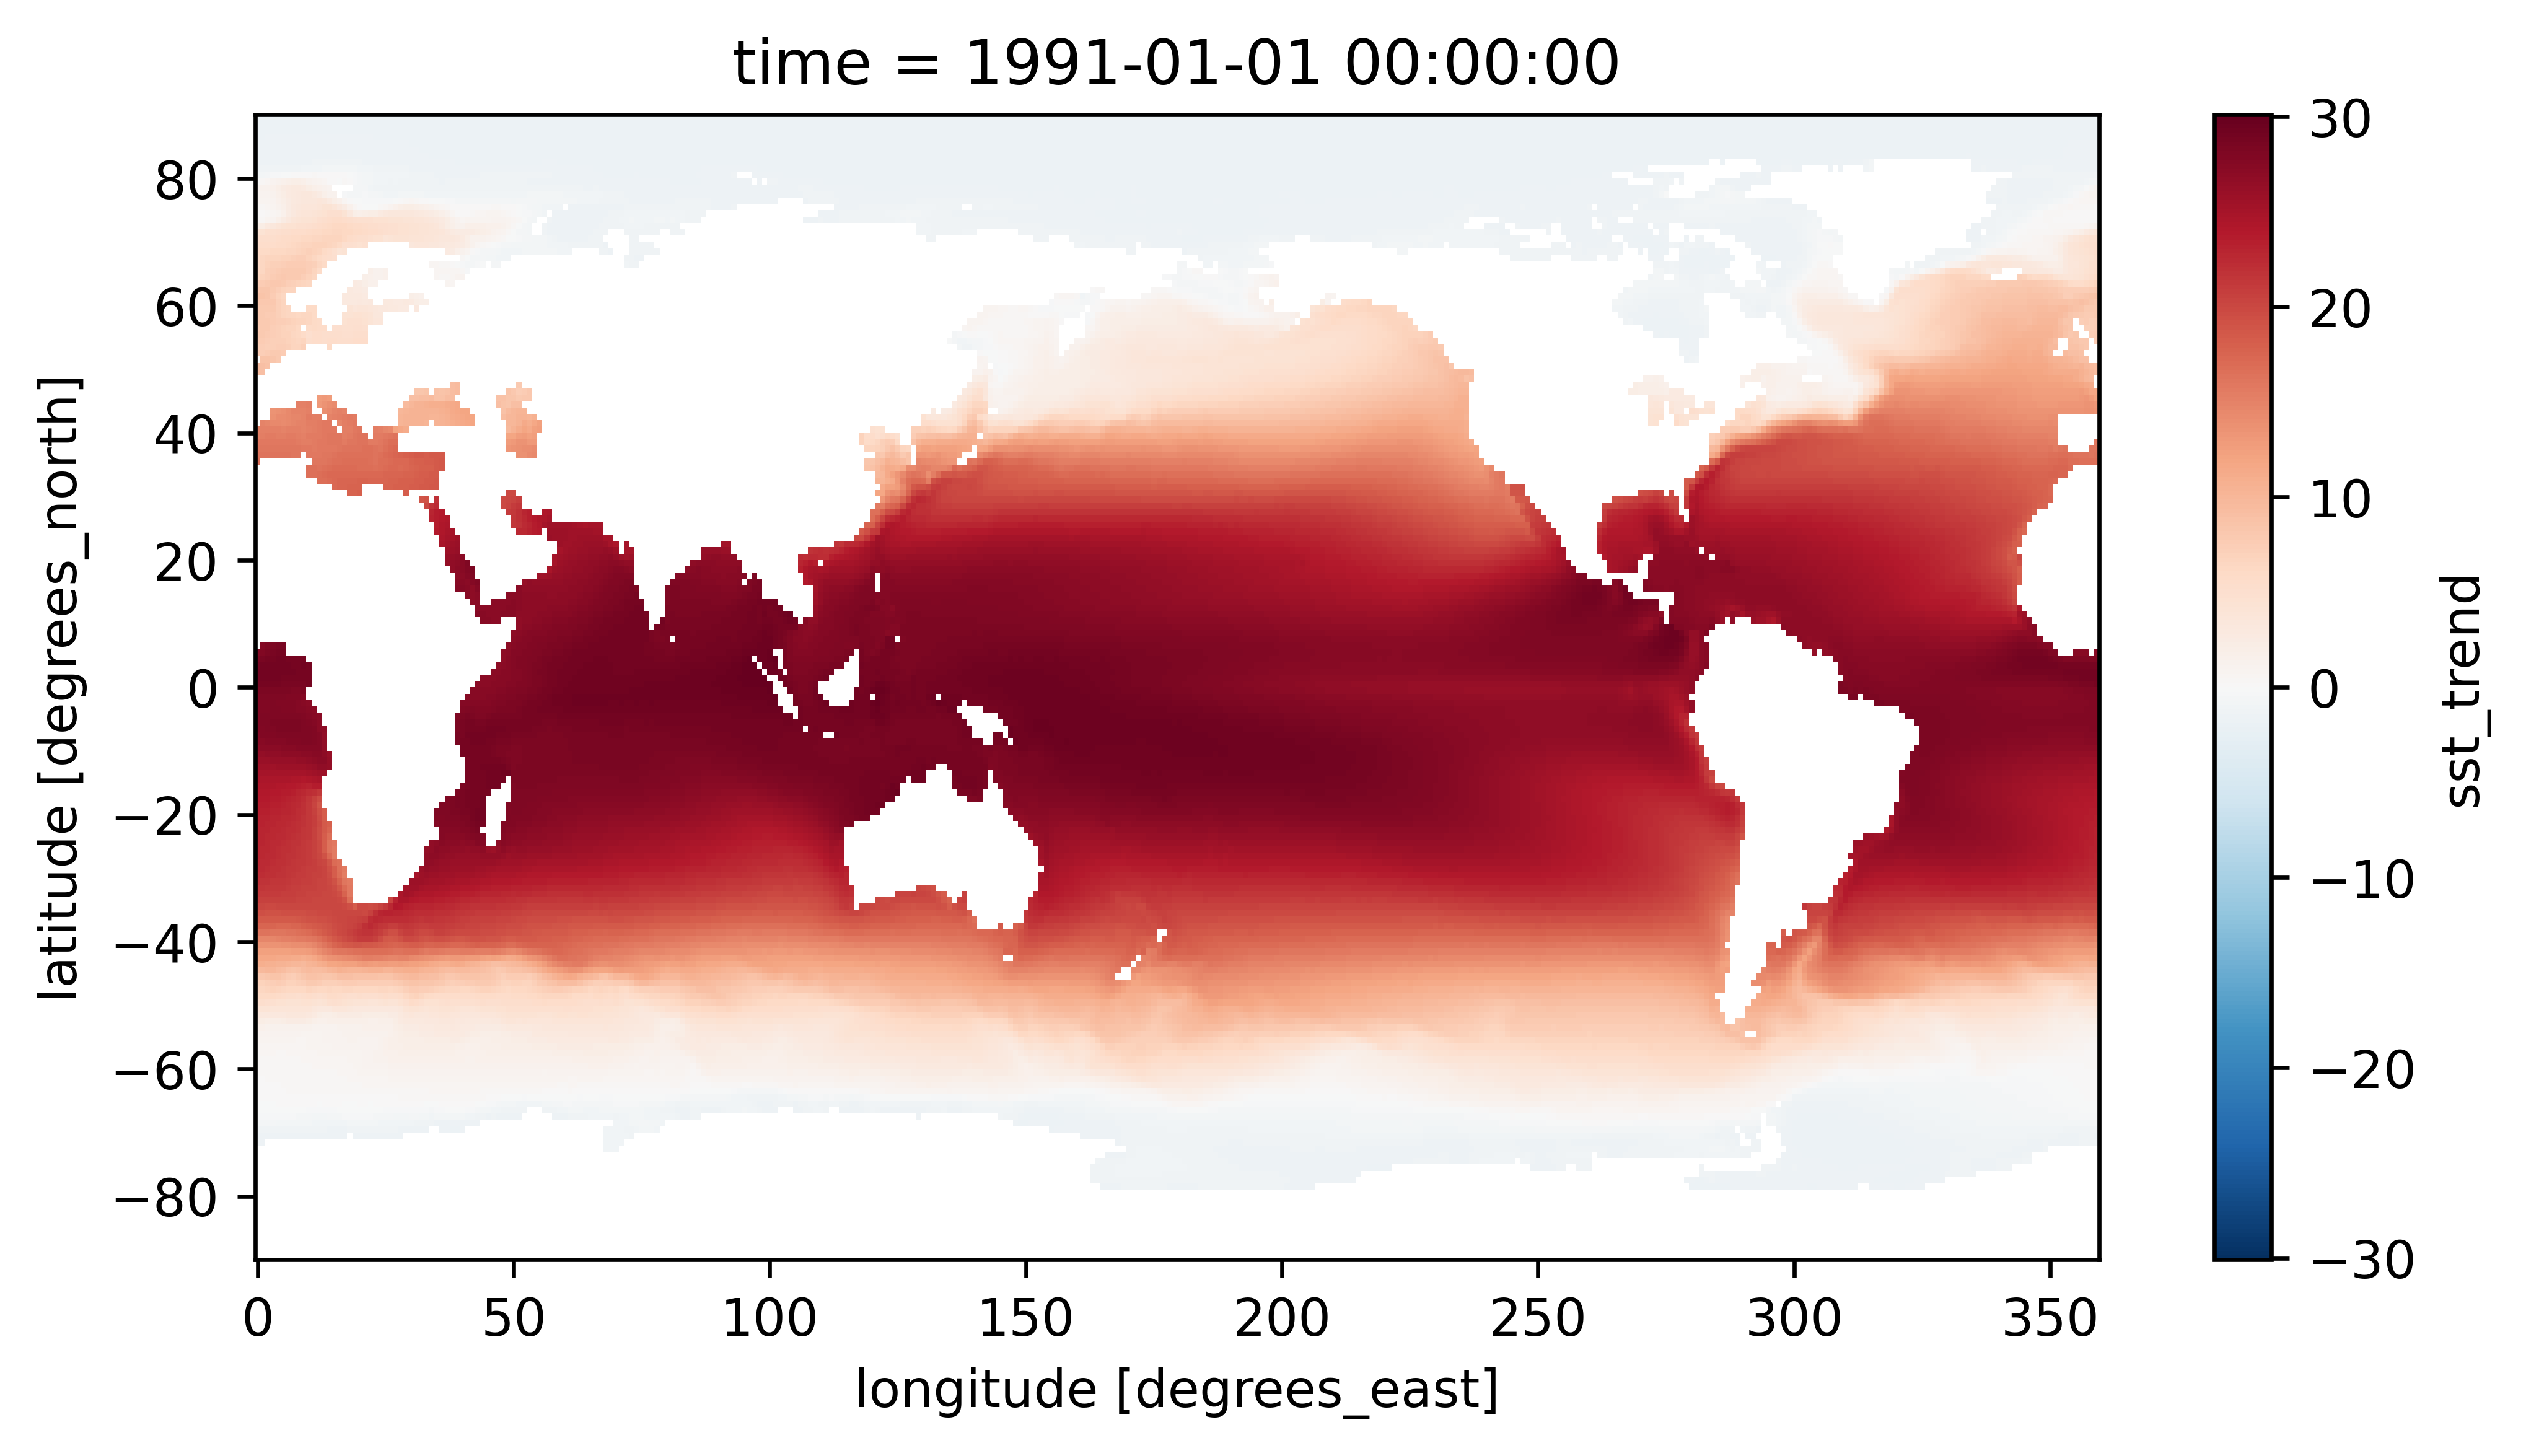

In [14]:
dsout.sst_trend.isel(time=0).plot()